<a href="https://colab.research.google.com/github/Bhuvana908/ML-Projects/blob/main/GAN-Based%20Low-Light%20Image%20Enhancement/GAN_Based_Low_Light_Image_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision opencv-python scikit-image matplotlib

In [2]:
!pip install kaggle
from google.colab import files
files.upload()  # upload kaggle.json only

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d soumikrakshit/lol-dataset
!unzip lol-dataset.zip -d data/
!ls data/our485/

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/lol-dataset
License(s): unknown
 93% 307M/331M [00:00<00:00, 803MB/s] 
100% 331M/331M [00:00<00:00, 714MB/s]
Archive:  lol-dataset.zip
  inflating: data/lol_dataset/eval15/high/1.png  
  inflating: data/lol_dataset/eval15/high/111.png  
  inflating: data/lol_dataset/eval15/high/146.png  
  inflating: data/lol_dataset/eval15/high/179.png  
  inflating: data/lol_dataset/eval15/high/22.png  
  inflating: data/lol_dataset/eval15/high/23.png  
  inflating: data/lol_dataset/eval15/high/493.png  
  inflating: data/lol_dataset/eval15/high/547.png  
  inflating: data/lol_dataset/eval15/high/55.png  
  inflating: data/lol_dataset/eval15/high/665.png  
  inflating: data/lol_dataset/eval15/high/669.png  
  inflating: data/lol_dataset/eval15/high/748.png  
  inflating: data/lol_dataset/eval15/high/778.png  
  inflating: data/lol_dataset/eval15/high/780.png  
  inflating: data/lol_dataset/eval15/high/79.png 

In [3]:
import os
print(os.listdir("data/lol_dataset/"))
print(os.listdir("data/lol_dataset/our485/"))

['our485', 'eval15']
['high', 'low']


In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from IPython.display import display

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE    = 256
BATCH_SIZE  = 4
EPOCHS      = 100
LR          = 2e-4
LAMBDA_L1   = 100
SAVE_EVERY  = 10
CHECKPOINT  = "checkpoints/"
RESULTS     = "results/"

os.makedirs(CHECKPOINT, exist_ok=True)
os.makedirs(RESULTS,    exist_ok=True)
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
class LOLDataset(Dataset):
    def __init__(self, low_dir, high_dir, transform=None):
        self.low_dir   = low_dir
        self.high_dir  = high_dir
        self.transform = transform
        self.images    = sorted(os.listdir(low_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]
        low  = Image.open(os.path.join(self.low_dir,  name)).convert("RGB")
        high = Image.open(os.path.join(self.high_dir, name)).convert("RGB")
        if self.transform:
            low  = self.transform(low)
            high = self.transform(high)
        return low, high

def get_transforms():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

In [7]:
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_dropout=False):
        super().__init__()
        if down:
            conv = nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)
        else:
            conv = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False)
        layers = [
            conv,
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True) if not down else nn.LeakyReLU(0.2, True)
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=64):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2, True)
        )
        self.enc2 = UNetBlock(features,     features * 2, down=True)
        self.enc3 = UNetBlock(features * 2, features * 4, down=True)
        self.enc4 = UNetBlock(features * 4, features * 8, down=True)
        self.enc5 = UNetBlock(features * 8, features * 8, down=True)
        self.enc6 = UNetBlock(features * 8, features * 8, down=True)
        self.enc7 = UNetBlock(features * 8, features * 8, down=True)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features * 8, features * 8, 4, 2, 1),
            nn.ReLU(True)
        )
        self.dec1 = UNetBlock(features * 8,     features * 8, down=False, use_dropout=True)
        self.dec2 = UNetBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.dec3 = UNetBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.dec4 = UNetBlock(features * 8 * 2, features * 8, down=False)
        self.dec5 = UNetBlock(features * 8 * 2, features * 4, down=False)
        self.dec6 = UNetBlock(features * 4 * 2, features * 2, down=False)
        self.dec7 = UNetBlock(features * 2 * 2, features,     down=False)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(features * 2, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        e6 = self.enc6(e5)
        e7 = self.enc7(e6)
        b  = self.bottleneck(e7)
        d1 = self.dec1(b)
        d2 = self.dec2(torch.cat([d1, e7], dim=1))
        d3 = self.dec3(torch.cat([d2, e6], dim=1))
        d4 = self.dec4(torch.cat([d3, e5], dim=1))
        d5 = self.dec5(torch.cat([d4, e4], dim=1))
        d6 = self.dec6(torch.cat([d5, e3], dim=1))
        d7 = self.dec7(torch.cat([d6, e2], dim=1))
        return self.final(torch.cat([d7, e1], dim=1))

print("Generator defined")

Generator defined


In [8]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=6, features=[64, 128, 256, 512]):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, features[0], 4, 2, 1),
            nn.LeakyReLU(0.2, True)
        ]
        for i in range(1, len(features)):
            stride = 1 if i == len(features) - 1 else 2
            layers += [
                nn.Conv2d(features[i-1], features[i], 4, stride, 1, bias=False),
                nn.BatchNorm2d(features[i]),
                nn.LeakyReLU(0.2, True)
            ]
        layers.append(nn.Conv2d(features[-1], 1, 4, 1, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, low, enhanced):
        x = torch.cat([low, enhanced], dim=1)
        return self.model(x)

print("Discriminator defined")

Discriminator defined


In [9]:
adversarial_loss = nn.BCEWithLogitsLoss()
l1_loss          = nn.L1Loss()

def generator_loss(disc_fake, fake_img, real_img):
    adv = adversarial_loss(disc_fake, torch.ones_like(disc_fake))
    l1  = l1_loss(fake_img, real_img) * LAMBDA_L1
    return adv + l1, adv, l1

def discriminator_loss(disc_real, disc_fake):
    real_loss = adversarial_loss(disc_real, torch.ones_like(disc_real))
    fake_loss = adversarial_loss(disc_fake, torch.zeros_like(disc_fake))
    return (real_loss + fake_loss) * 0.5

def tensor_to_numpy(tensor):
    img = tensor.detach().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img.transpose(1, 2, 0)

def compute_metrics(fake_batch, real_batch):
    psnr_scores, ssim_scores = [], []
    for fake, real in zip(fake_batch, real_batch):
        f = tensor_to_numpy(fake)
        r = tensor_to_numpy(real)
        psnr_scores.append(psnr(r, f, data_range=255))
        ssim_scores.append(ssim(r, f, channel_axis=2, data_range=255))
    return np.mean(psnr_scores), np.mean(ssim_scores)

def save_samples(epoch, low, fake, real):
    low_d  = low  * 0.5 + 0.5
    fake_d = fake * 0.5 + 0.5
    real_d = real * 0.5 + 0.5
    comparison = torch.cat([low_d[:4], fake_d[:4], real_d[:4]], dim=0)
    save_image(comparison, f"{RESULTS}epoch_{epoch:03d}.png", nrow=4)
    print(f"Saved samples → {RESULTS}epoch_{epoch:03d}.png")

print("Loss functions and metrics defined")

Loss functions and metrics defined


In [10]:
G = UNetGenerator().to(DEVICE)
D = PatchGANDiscriminator().to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

tf = get_transforms()
train_dataset = LOLDataset("data/lol_dataset/our485/low", "data/lol_dataset/our485/high", transform=tf)
val_dataset   = LOLDataset("data/lol_dataset/eval15/low", "data/lol_dataset/eval15/high", transform=tf)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 485 | Val: 15


In [11]:
history = {"g_loss": [], "d_loss": [], "psnr": [], "ssim": []}

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    g_losses, d_losses = [], []

    for low, high in train_loader:
        low, high = low.to(DEVICE), high.to(DEVICE)

        # Train Discriminator
        fake = G(low)
        disc_real = D(low, high)
        disc_fake = D(low, fake.detach())
        d_loss = discriminator_loss(disc_real, disc_fake)
        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # Train Generator
        disc_fake = D(low, fake)
        g_loss, _, _ = generator_loss(disc_fake, fake, high)
        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    # Validation
    G.eval()
    val_psnr, val_ssim = [], []
    with torch.no_grad():
        for low, high in val_loader:
            low, high = low.to(DEVICE), high.to(DEVICE)
            fake = G(low)
            p, s = compute_metrics(fake, high)
            val_psnr.append(p)
            val_ssim.append(s)

    avg_g    = np.mean(g_losses)
    avg_d    = np.mean(d_losses)
    avg_psnr = np.mean(val_psnr)
    avg_ssim = np.mean(val_ssim)

    history["g_loss"].append(avg_g)
    history["d_loss"].append(avg_d)
    history["psnr"].append(avg_psnr)
    history["ssim"].append(avg_ssim)

    print(f"Epoch [{epoch:3d}/{EPOCHS}] G: {avg_g:.4f} | D: {avg_d:.4f} | PSNR: {avg_psnr:.2f} dB | SSIM: {avg_ssim:.4f}")

    if epoch % SAVE_EVERY == 0:
        with torch.no_grad():
            low_s, high_s = next(iter(val_loader))
            low_s = low_s.to(DEVICE)
            fake_s = G(low_s)
        save_samples(epoch, low_s, fake_s, high_s.to(DEVICE))
        torch.save(G.state_dict(), f"{CHECKPOINT}G_epoch_{epoch}.pth")
        torch.save(D.state_dict(), f"{CHECKPOINT}D_epoch_{epoch}.pth")

print("Training complete!")

Epoch [  1/100] G: 31.7761 | D: 0.4323 | PSNR: 8.15 dB | SSIM: 0.0537
Epoch [  2/100] G: 28.2379 | D: 0.1868 | PSNR: 14.10 dB | SSIM: 0.2501
Epoch [  3/100] G: 27.3018 | D: 0.0558 | PSNR: 15.70 dB | SSIM: 0.2888
Epoch [  4/100] G: 26.7876 | D: 0.1009 | PSNR: 16.49 dB | SSIM: 0.3862
Epoch [  5/100] G: 25.6176 | D: 0.1321 | PSNR: 16.15 dB | SSIM: 0.4341
Epoch [  6/100] G: 26.6724 | D: 0.0117 | PSNR: 10.59 dB | SSIM: 0.2194
Epoch [  7/100] G: 25.5256 | D: 0.1521 | PSNR: 12.95 dB | SSIM: 0.3571
Epoch [  8/100] G: 24.5172 | D: 0.2116 | PSNR: 13.93 dB | SSIM: 0.4797
Epoch [  9/100] G: 23.2306 | D: 0.2987 | PSNR: 19.10 dB | SSIM: 0.6385
Epoch [ 10/100] G: 20.5488 | D: 0.5448 | PSNR: 15.41 dB | SSIM: 0.5173
Saved samples → results/epoch_010.png
Epoch [ 11/100] G: 21.5584 | D: 0.4505 | PSNR: 18.54 dB | SSIM: 0.6162
Epoch [ 12/100] G: 23.0158 | D: 0.1198 | PSNR: 16.99 dB | SSIM: 0.4713
Epoch [ 13/100] G: 23.5003 | D: 0.1623 | PSNR: 18.30 dB | SSIM: 0.5814
Epoch [ 14/100] G: 22.9005 | D: 0.1851 |

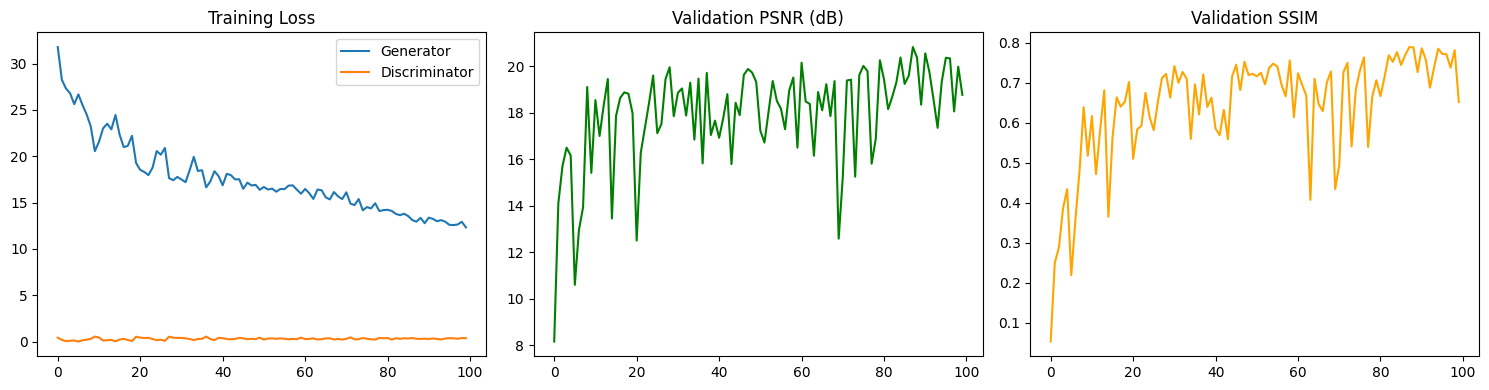

Final PSNR: 18.76 dB
Final SSIM: 0.6516


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["g_loss"], label="Generator")
axes[0].plot(history["d_loss"], label="Discriminator")
axes[0].set_title("Training Loss"); axes[0].legend()
axes[1].plot(history["psnr"], color="green")
axes[1].set_title("Validation PSNR (dB)")
axes[2].plot(history["ssim"], color="orange")
axes[2].set_title("Validation SSIM")
plt.tight_layout(); plt.show()

print(f"Final PSNR: {history['psnr'][-1]:.2f} dB")
print(f"Final SSIM: {history['ssim'][-1]:.4f}")

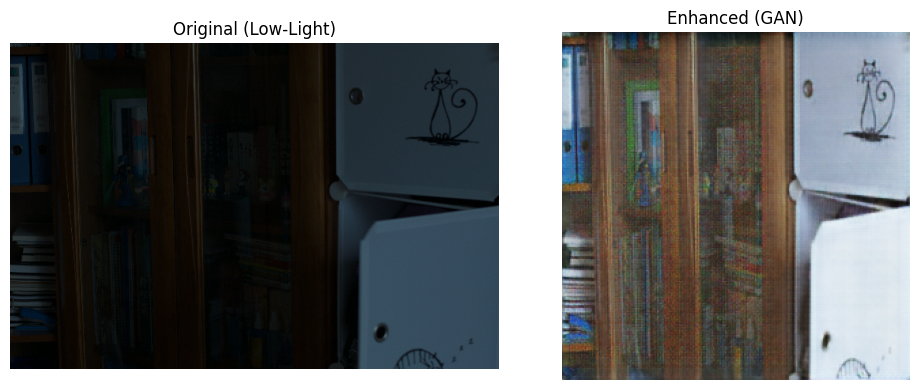

In [13]:
G.eval()
img_path = "data/lol_dataset/eval15/low/1.png"
img = Image.open(img_path).convert("RGB")

tensor = get_transforms()(img).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    enhanced = G(tensor).squeeze(0)

enhanced = (enhanced * 0.5 + 0.5).clamp(0, 1)
enhanced_np = (enhanced.cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img);                          axes[0].set_title("Original (Low-Light)"); axes[0].axis("off")
axes[1].imshow(Image.fromarray(enhanced_np)); axes[1].set_title("Enhanced (GAN)");       axes[1].axis("off")
plt.tight_layout(); plt.show()

In [14]:
import torch

# Define the filename
model_save_path = "lol_generator_v1.pth"

# Save the weights
# We use G.state_dict() to save only the learned parameters
torch.save(G.state_dict(), model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to lol_generator_v1.pth
